In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from shapely.geometry import LineString, Point, Polygon

from pyproj import Transformer 

import pandas as pd
import numpy as np

In [3]:
# configure the place, network type, trip times, and travel speed
#place = {"city": "Berkeley", "state": "California"}
#place = "Vienna, Austria"
#place = "Vorarlberg, Austria"
target_crs = "epsg:31287"

places = [{"city": "Vienna", "country": "Austria"},
          {"state": "Lower Austria", "country": "Austria"},
          {"state": "Upper Austria", "country": "Austria"},
          {"state": "Burgenland", "country": "Austria"},
          {"state": "Salzburg", "country": "Austria"},
          {"state": "Styria", "country": "Austria"},
          {"state": "Carinthia", "country": "Austria"},
          {"state": "Tyrol", "country": "Austria"},
          {"state": "Vorarlberg", "country": "Austria"}]

network_type = "walk"

# TODO: change place/region to desired values
place = {"city": "Bregenz", "country": "Austria"}
region = "vmobil_obb_20240528.csv"

distances = [300, 500, 750, 1000, 1250]
ptsql_colors = ["#E42421", "#E95153", "#E63C1E", "#F29668", "#34672B", "#87C281", "#959595", "none"]

path_graphs_out = "../data/in/osmnx_graphs/"
path_stops_in = "../data/out/stop_dfs/"

In [4]:
ptsql_color_table = [[0,0,1,2,3], # I
                    [0,1,2,3,4], # II
                    [1,2,3,4,5], # III
                    [2,3,4,5,6], # IV
                    [3,4,5,6,6], # V
                    [4,5,6,-1,-1], # VI
                    [5,6,6,-1,-1], # VII
                    [6,6,-1,-1,-1]] # VIII

def assign_color(category, distance):
    """
    Lookup the ptsql based on the station category and the distance level.
    """
    if distance <= 300:
        return ptsql_color_table[category][0]
    elif distance <= 500:
        return ptsql_color_table[category][1]
    elif distance <= 750:
        return ptsql_color_table[category][2]
    elif distance <= 1000:
        return ptsql_color_table[category][3]
    elif distance <= 1250:
        return ptsql_color_table[category][4]
    else:
        return -1

In [5]:
def draw_graph(G, ns=0, nc="none", gdf=None, return_fig=False):
    fig, ax = ox.plot.plot_graph(
        G,
        node_color=nc,
        node_size=ns,
        edge_color="#999999",
        edge_alpha=0.2,
        show=False,
        close=False,
        figsize=(12, 12),
        dpi=300,
    )
    if gdf is not None:
        gdf.plot(ax=ax, color=gdf.index, ec="none", alpha=1, zorder=-1)

    #plt.show()

    if return_fig:
        return fig, ax

## Download and prep the street network

In [6]:
# download the street network
name = place.get("state", place.get("city"))
#G = ox.graph.graph_from_place(place, network_type=network_type,)# simplify=False)
# TODO: maybe use "simplify=False" to get the full street network

In [7]:
# load or save graph from/to folder

#ox.save_graphml(G, f"{path_graphs_out}/graph_{name}.graphml")

G = ox.load_graphml(f"{path_graphs_out}/graph_{name}.graphml")

In [8]:
# project graph to target crs (epsg:31287)
G = ox.projection.project_graph(G, to_crs=target_crs)

In [9]:
# export  as geopackage for qgis

# edges = ox.graph_to_gdfs(G, nodes=False)
# edges.to_file(f"{path_graphs_out}/graph_{name}.gpkg", driver="GPKG")

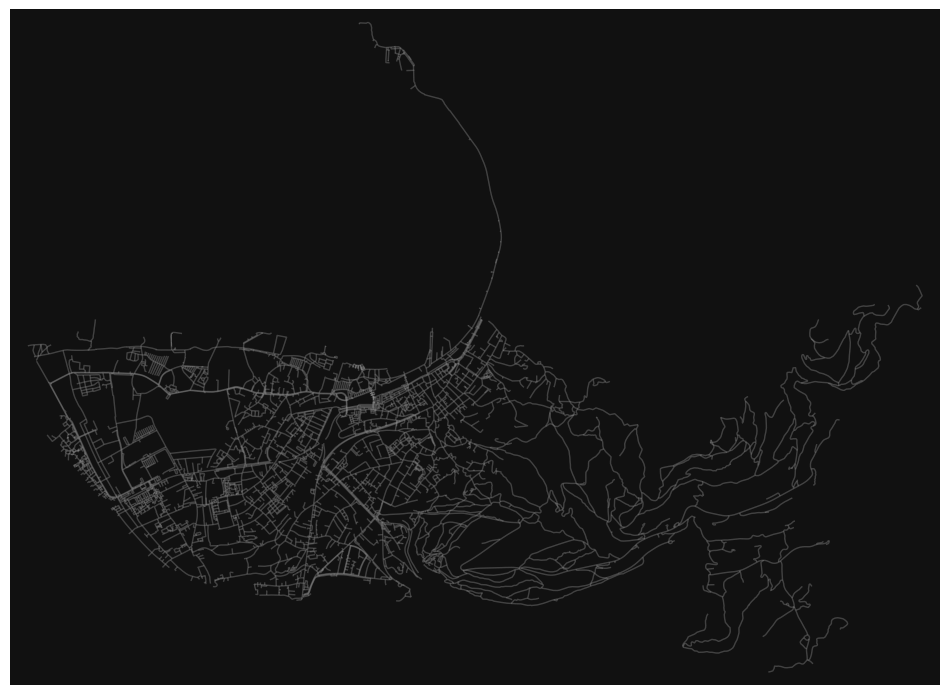

In [10]:
draw_graph(G)

In [11]:
# load stop data for region
df = pd.read_csv(f"{path_stops_in}{region}")

# project coordinates to target crs
transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
df["x"], df["y"] = transformer.transform(df["stop_lon"].values, df["stop_lat"].values)

df

,stop_id,stop_name,stop_lat,stop_lon,rank,count,interval,category,x,y
0,at:41:3087,Bad Sauerbrunn Bahnhof,47.773870,16.324886,1,45,37.333333,3,624147.999060,434803.244360
1,at:41:3145,Baumgarten-Schattendorf Bahnhof,47.727514,16.518257,0,35,48.000000,3,638836.142430,430230.274027
2,at:41:3186,Breitenbrunn Bahnhof,47.941229,16.746385,0,45,37.333333,2,654886.428000,454687.635894
3,at:41:3294,Deutschkreutz Bahnhof,47.603827,16.620054,0,43,39.069767,2,647044.394373,416812.655577
4,at:41:3298,Donnerskirchen Bahnhof,47.888571,16.660416,0,45,37.333333,2,648722.031041,448561.691384
...,...,...,...,...,...,...,...,...,...,...
2640,at:49:910,Wien Aspern Nord,48.233852,16.504630,0,115,14.608696,1,635520.675129,486424.549717
2641,at:49:94,Wien Atzgersdorf,48.147016,16.288657,1,173,9.710983,1,619859.845816,476146.862578
2642,at:49:948,Wien Nußdorf,48.260209,16.367664,1,54,31.111111,3,625242.231223,488946.632002
2643,at:49:959,Wien Oberdöbling,48.244011,16.344101,1,168,10.000000,1,623564.154413,487079.359723


## Test to find nodes closest node to given station coordinates
(needed to run later code)

In [12]:

nc = []
ns = []

# find closest node in network to each stop
nodes, dists = ox.nearest_nodes(G, df['x'], df['y'], return_dist=True)
print(len(nodes))


node_list = np.rec.fromarrays([nodes, df["stop_id"], df['category']])

print(node_list)
print(len(node_list))

# test: assign a color to each node based on the distance to its correct stop position
bins = [10, 25, 50, 1000]
colors = np.array(["green", "yellow", "orange", "red", "black"])
node_colors = colors[np.digitize(dists, bins)]

for n in G.nodes():
    if n in nodes:
        c = node_colors[np.where(nodes == n)[0][0]]
        if c != 'black':
            ns.append(15)
            nc.append(c)
        else:
            ns.append(0)
            nc.append("none")
    else:
        ns.append(0)
        nc.append("none")


2645
[(11162779196, 'at:41:3087', 3) (11162779196, 'at:41:3145', 3)
 (11162779196, 'at:41:3186', 2) ... (11162779196, 'at:49:948', 3)
 (11162779196, 'at:49:959', 1) (11162779196, 'at:49:981', 1)]
2645


In [13]:
print(np.unique(node_colors, return_counts=True))

(array(['black', 'green', 'orange', 'red', 'yellow'], dtype='<U6'), array([2517,   39,    8,   50,   31]))


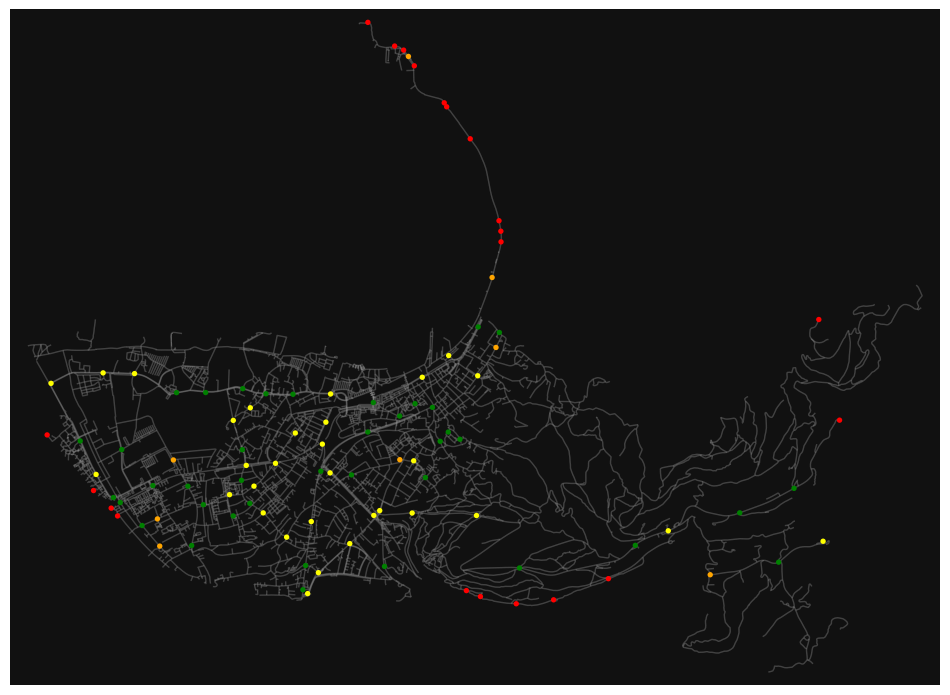

In [14]:
draw_graph(G, ns, nc)

# green: node withing 10m of actual location
# yellow: node withing 25m of actual location
# orange: node withing 50m of actual location
# red: nodes even further away
# red also contains nodes outside of bregenz.

## Plot the time-distances as isochrones

In [22]:
# make the isochrone polygons
isochrone_polys = []
for cn,_,cat in node_list:
    for d in sorted(distances, reverse=True):
        subgraph = nx.ego_graph(G, cn, radius=d, distance="length")
        node_points = [Point((data["x"], data["y"])) for node, data in subgraph.nodes(data=True)]
        bounding_poly = gpd.GeoSeries(node_points).union_all().convex_hull.buffer(1)
        isochrone_polys.append({
            "center": cn,
            #"distance": d,
            #"category": cat,
            "color": ptsql_colors[assign_color(cat,d)],
            "geometry": bounding_poly
        })
gdf = gpd.GeoDataFrame(isochrone_polys)

                                                  geometry       center
color                                                                  
none     MULTIPOLYGON (((127696.17 405159.02, 127696.16...  10795949940
#959595  MULTIPOLYGON (((127696.165 405159.023, 127696....  11162779196
#87C281  MULTIPOLYGON (((127572.028 405256.874, 127572....  11162779196
#34672B  MULTIPOLYGON (((127696.164 405159.024, 127696....  11162779196
#F29668  MULTIPOLYGON (((127696.171 405159.019, 127696....  11162779196
#E63C1E  MULTIPOLYGON (((127696.255 405158.972, 127696....  11162779196
#E95153  MULTIPOLYGON (((127942.724 405042.16, 127942.7...  11162779196
#E42421  MULTIPOLYGON (((128900.974 404876.686, 128900....  11162779196


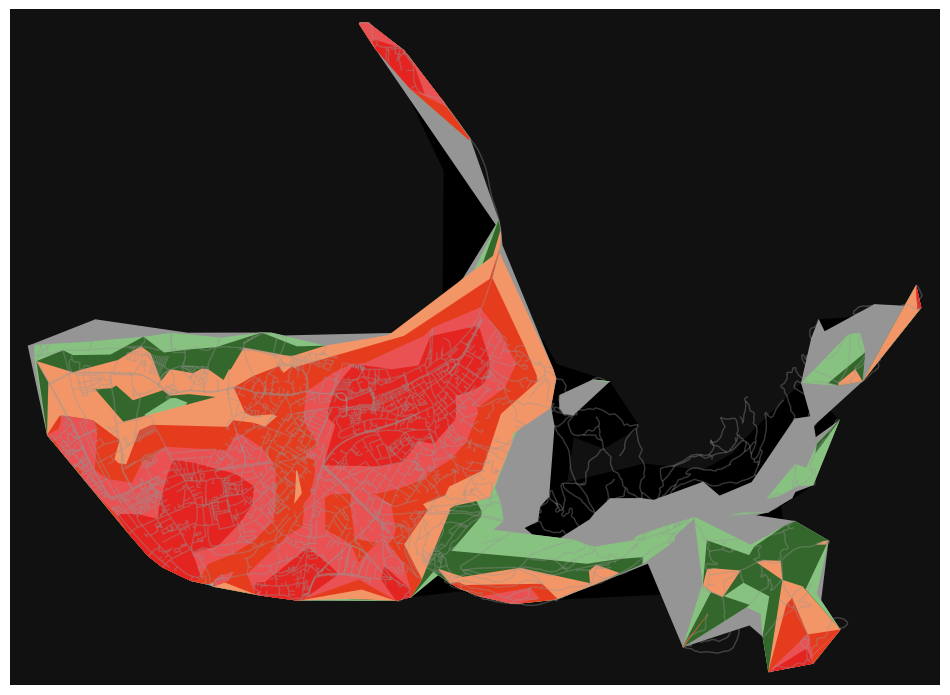

In [23]:
# dissolve all entries with the same color into one and 
# sort by color to plot lower rank colors first and higher rank colors on top
gdf_dissolved = gdf.dissolve(by="color").reindex(ptsql_colors[::-1])

print(gdf_dissolved)

draw_graph(G, gdf=gdf_dissolved)

## Faster version without re-selecting nodes in inner distances

In [20]:
records = []

for cn,_,cat in node_list:

    # select all nodes within the max distance
    lengths = nx.single_source_dijkstra_path_length(
        G,
        cn,
        cutoff=distances[-1],
        weight="length"
    )

    prev_d = 0
    # for each distance, select all nodes in the distance band
    for d in distances:
        ring_nodes = [ Point((G.nodes[n]["x"], G.nodes[n]["y"])) for n, dist in lengths.items() if prev_d < dist <= d ]

        if ring_nodes:
            poly = gpd.GeoSeries(ring_nodes).union_all().convex_hull.buffer(1)
            records.append({
                "center": cn,
                "distance": d,
                "color": ptsql_colors[assign_color(cat, d)],
                "geometry": poly
            })

        prev_d = d

# edges = ox.graph_to_gdfs(G.subgraph(lengths.keys()), nodes=False)
# iso_poly = edges.buffer(20).unary_union


gdf = gpd.GeoDataFrame(records, crs=G.graph["crs"])

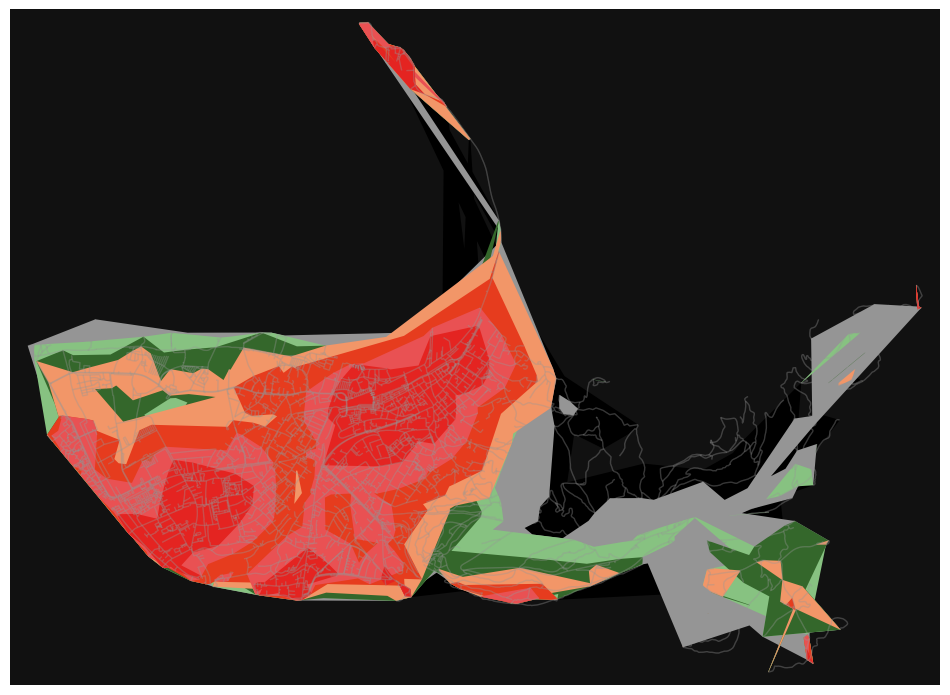

In [21]:
#print(gdf.head())

gdf_dissolved = gdf.dissolve(by="color").reindex(ptsql_colors[::-1])

#print(gdf_dissolved)

draw_graph(G, gdf=gdf_dissolved)

In [ ]:
#gdf_dissolved.to_file(f"{data_path}/dissolved_{place.split(',')[0]}.gpkg", driver="GPKG", layer="isochrones")